# HW4 - statistics and data analysis.
# Differential Gene Expression in Acute Myocardial Infarction

**Dataset:** GSE66360 - Circulating Endothelial Cells (CECs) gene expression profiling  
**Source:** Muse et al., Sci Rep 2017  
**Platform:** Affymetrix Human Genome U133 Plus 2.0 Array (GPL570)  

**Goal:** Compare expression profiles of CECs in patients with acute myocardial infarction (AMI) to CECs in healthy controls.

## 2. The Data Set

### Data Loading and Pre-processing:

The raw CSV file (`AMI_GSE66360_series_matrix.csv`) is a GEO series matrix file that contains:
- **Lines 1-57:** Series-level and sample-level metadata (study info, contact details, protocols, etc.)
- **Line 58:** `!series_matrix_table_begin` marker
- **Line 60:** Class labels — `H` (Healthy) and `M` (Myocardial Infarction)
- **Line 61:** `ID_REF` header with sample accession IDs (GSM...)
- **Lines 62–54736:** Expression values (54,675 probe sets × 99 samples)

We need to:
1. Remove all metadata rows that are not relevant to the analysis
2. Keep the class labels (H/M) for each sample
3. Keep all expression values
4. Keep the probe set IDs (ID_REF)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 10)
pd.set_option('display.max_rows', 20)

In [3]:
# --- Load the raw CSV ---
# The file has metadata in lines 1-58, then an empty line 59.
# Line 60 has: Class, H, H, H, ..., M, M, M  (the class labels)
# Line 61 has: ID_REF, GSM1620819, GSM1620820, ... (sample IDs)
# Lines 62+: expression data (probe_id, value1, value2, ...)
#
# We read starting from the Class row (line 60, 0-indexed row 59) with no header,
# so we get full control over parsing.

raw = pd.read_csv(
    'AMI_GSE66360_series_matrix.csv',
    skiprows=59,
    header=None,
    index_col=0,
    encoding='latin-1',
    low_memory=False
)

# The index column (col 0) has: 'Class', 'ID_REF', '1007_s_at', '1053_at', ...
# Remove any fully-empty trailing columns (from the CSV having extra commas)
raw = raw.loc[:, raw.notna().any()]

print(f'Raw table shape: {raw.shape}')
raw.head(3)

Raw table shape: (54677, 99)


,1,2,3,4,5,...,95,96,97,98,99
0,,,,,,,,,,,
Class,H,H,H,H,H,...,M,M,M,M,M
ID_REF,GSM1620819,GSM1620820,GSM1620821,GSM1620822,GSM1620823,...,GSM1620913,GSM1620914,GSM1620915,GSM1620916,GSM1620917
1007_s_at,5.866377893,4.948736331,5.148384393,5.064418945,5.017832878,...,6.472517225,5.678815851,5.653286378,6.013841046,5.465333944


In [4]:
# --- Extract class labels and sample IDs ---
# Row with index 'Class' contains H/M labels; row 'ID_REF' has sample accession IDs.

class_row = raw.loc['Class']        # H, H, ..., M, M, ...
sample_ids = raw.loc['ID_REF']      # GSM1620819, GSM1620820, ...

# Build a sample-info table: sample accession ID → class label
sample_info = pd.DataFrame({
    'sample_id': sample_ids.values,
    'label': class_row.values
})

print('Class label distribution:')
print(sample_info['label'].value_counts())
print(f'\nTotal samples: {len(sample_info)}')
sample_info.head(10)

Class label distribution:
label
H    50
M    49
Name: count, dtype: int64

Total samples: 99


,sample_id,label
0,GSM1620819,H
1,GSM1620820,H
2,GSM1620821,H
3,GSM1620822,H
4,GSM1620823,H
5,GSM1620824,H
6,GSM1620825,H
7,GSM1620826,H
8,GSM1620827,H
9,GSM1620828,H


In [5]:
# --- Build the clean expression matrix ---
# Drop the 'Class' and 'ID_REF' rows, keeping only the numeric expression data.
# Set the column names to the actual sample accession IDs.

expr = raw.drop(['Class', 'ID_REF'])
expr.columns = sample_ids.values           # rename columns to GSM... IDs
expr = expr.astype(float)                  # convert all values to float
expr.index.name = 'probe_id'

print(f'Expression matrix shape: {expr.shape}')
print(f'  Probes (genes): {expr.shape[0]}')
print(f'  Samples:        {expr.shape[1]}')
expr.head()

Expression matrix shape: (54675, 99)
  Probes (genes): 54675
  Samples:        99


,GSM1620819,GSM1620820,GSM1620821,GSM1620822,GSM1620823,...,GSM1620913,GSM1620914,GSM1620915,GSM1620916,GSM1620917
probe_id,,,,,,,,,,,
1007_s_at,5.866378,4.948736,5.148384,5.064419,5.017833,...,6.472517,5.678816,5.653286,6.013841,5.465334
1053_at,8.225790,7.525865,7.764637,7.198461,7.831450,...,8.261422,6.925753,7.918424,7.442701,9.225221
117_at,6.179732,6.628137,5.859151,5.974135,6.793079,...,6.367759,6.835756,7.577035,7.147417,6.481128
121_at,6.179478,6.582889,6.602135,6.545905,5.911542,...,6.440978,6.955883,6.499215,6.587065,6.897591
1255_g_at,2.792048,2.695714,2.580181,2.712124,2.723687,...,3.730139,2.914868,3.013901,2.729320,3.151449


In [6]:
# --- Verify data integrity ---
nan_count = expr.isnull().sum().sum()
nan_probes = expr.isnull().any(axis=1).sum()
print(f'Total NaN values: {nan_count}')
print(f'Probes with at least one NaN: {nan_probes}')
print(f'Note: We keep ALL {expr.shape[0]} probes as instructed (no rows dropped).')

print(f'\nExpression value range: [{expr.min().min():.2f}, {expr.max().max():.2f}]')
print(f'The data is RMA-normalized (log2 scale), as stated in the GEO record.')

Total NaN values: 47
Probes with at least one NaN: 47
Note: We keep ALL 54675 probes as instructed (no rows dropped).

Expression value range: [1.49, 14.90]
The data is RMA-normalized (log2 scale), as stated in the GEO record.


In [7]:
# --- Split samples by class ---
healthy_samples = sample_info[sample_info['label'] == 'H']['sample_id'].tolist()
ami_samples = sample_info[sample_info['label'] == 'M']['sample_id'].tolist()

expr_healthy = expr[healthy_samples]
expr_ami = expr[ami_samples]

print(f'Healthy (H) samples: {expr_healthy.shape[1]}')
print(f'AMI (M) samples:     {expr_ami.shape[1]}')

Healthy (H) samples: 50
AMI (M) samples:     49


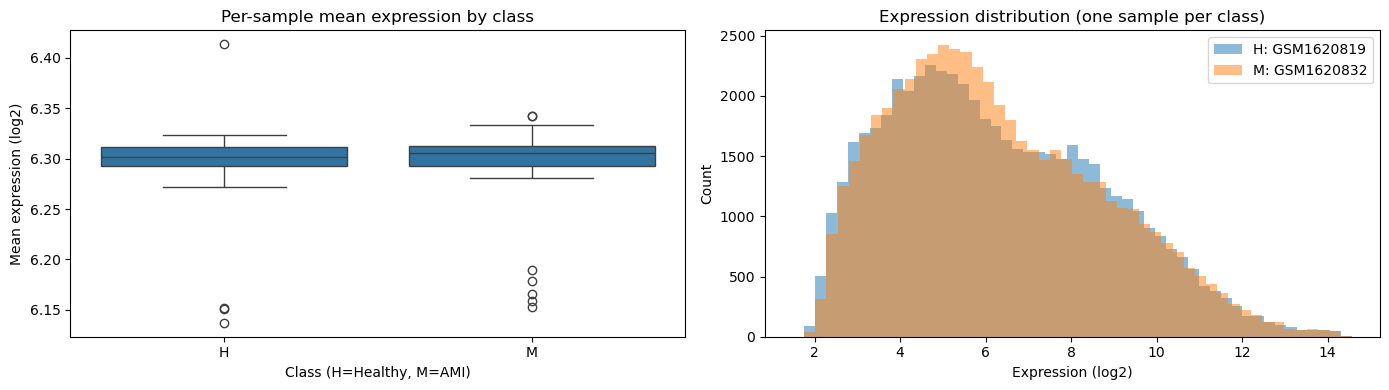

In [ ]:
# --- Distribution of mean expression per sample ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Boxplot of per-sample means by class
means = expr.mean()
means_df = pd.DataFrame({'mean_expr': means.values, 'label': class_row.values})
sns.boxplot(data=means_df, x='label', y='mean_expr', ax=axes[0])
axes[0].set_title('Per-sample mean expression by class')
axes[0].set_xlabel('Class (H=Healthy, M=AMI)')
axes[0].set_ylabel('Mean expression (log2)')

# Histogram of expression values for one random sample from each class
axes[1].hist(expr[healthy_samples[0]], bins=50, alpha=0.5, label=f'H: {healthy_samples[0]}')
axes[1].hist(expr[ami_samples[0]], bins=50, alpha=0.5, label=f'M: {ami_samples[0]}')
axes[1].set_title('Expression distribution (one sample per class)')
axes[1].set_xlabel('Expression (log2)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

### Pre-processing summary

We removed all metadata rows (series information, contact details, protocols, platform info, etc.) that are not needed for statistical analysis. We retained:

- **Class labels** (H = Healthy, M = Myocardial Infarction) for each of the 99 samples
- **All expression values** — 54,675 probe sets × 99 samples, RMA-normalized (log2 scale), no probes removed
- **Probe set IDs** as the row index

The data is now ready for downstream analysis.

## 3. Analysis

### a. High level description of the data and some pre-processing

In [9]:
# --- 1) How many genes (probes) are profiled? ---
print(f'1) Number of genes (probe sets) profiled: {expr.shape[0]}')

1) Number of genes (probe sets) profiled: 54675


In [10]:
# --- 2) How many samples (subjects/patients) in total? ---
print(f'2) Total number of samples (subjects): {expr.shape[1]}')

2) Total number of samples (subjects): 99


In [11]:
# --- 3) How many samples in each class? ---
print('3) Samples per class:')
print(f'   H (Healthy):                {len(healthy_samples)}')
print(f'   M (Myocardial Infarction):  {len(ami_samples)}')

3) Samples per class:
   H (Healthy):                50
   M (Myocardial Infarction):  49


In [12]:
# --- 4) Remove rows (genes) with any missing values ---
print(f'4) Before removing NaN rows: {expr.shape[0]} genes')

expr = expr.dropna(axis=0)

print(f'   After removing NaN rows:  {expr.shape[0]} genes')
print(f'   Rows removed: {54675 - expr.shape[0]}')

# Update the class-split matrices after dropping NaN rows
expr_healthy = expr[healthy_samples]
expr_ami = expr[ami_samples]

4) Before removing NaN rows: 54675 genes
   After removing NaN rows:  54628 genes
   Rows removed: 47


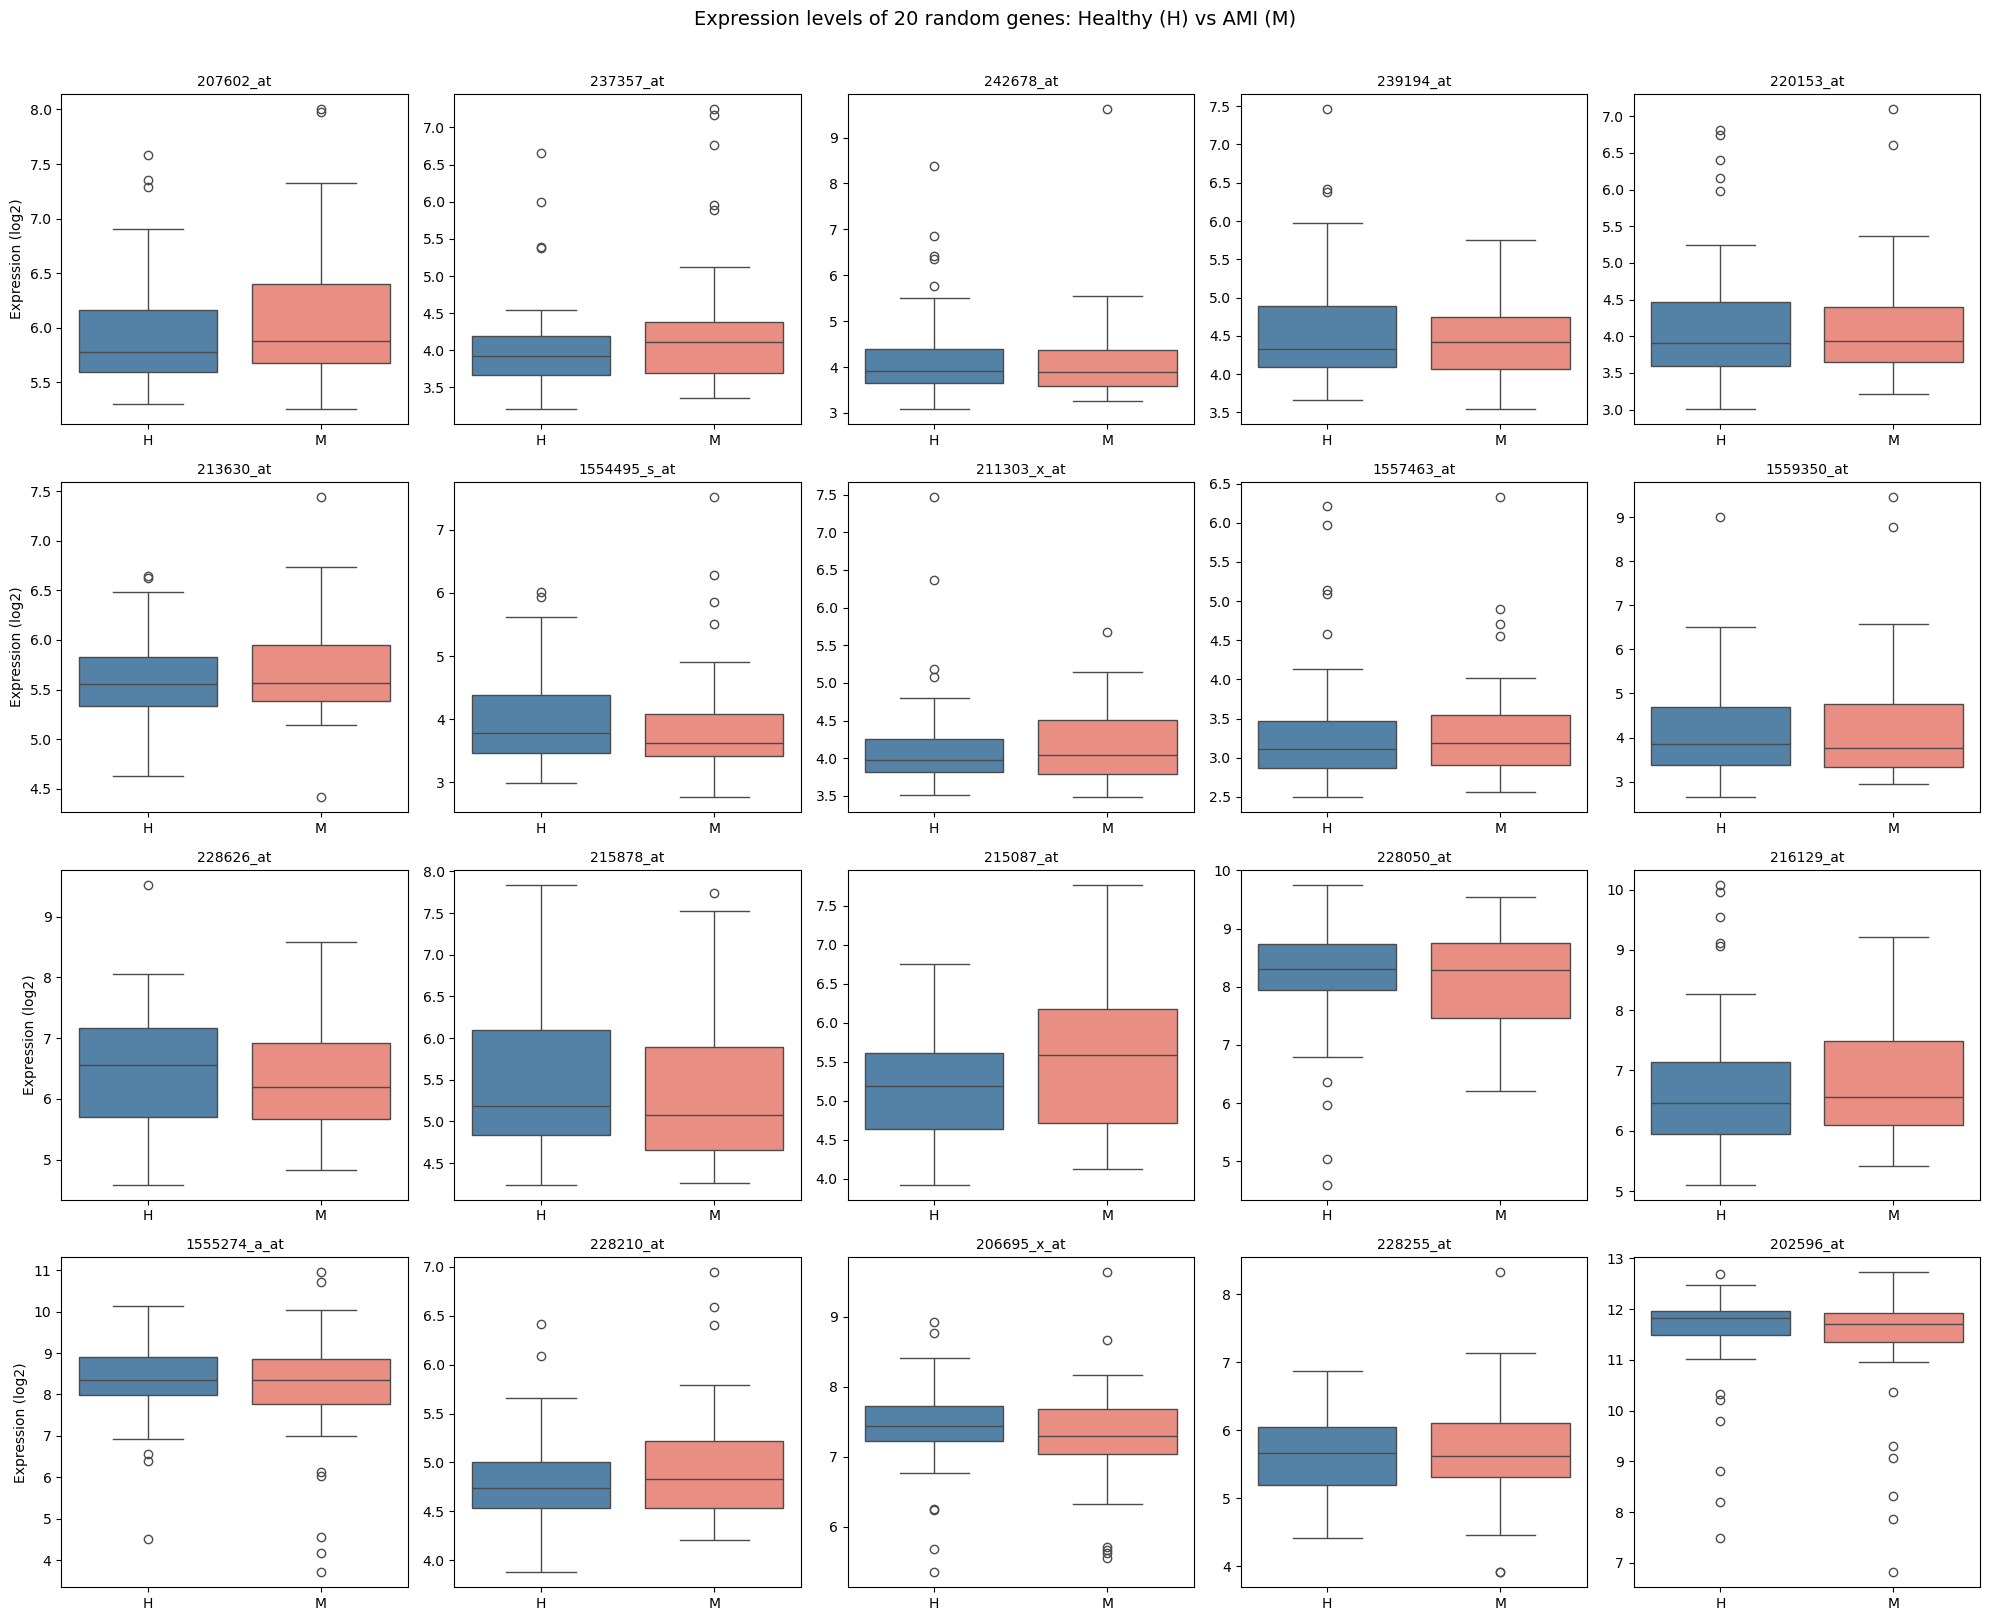

In [13]:
# --- 5) Boxplots for 20 random genes comparing M vs H ---
np.random.seed(42)  # for reproducibility
random_genes = np.random.choice(expr.index, size=20, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

for i, gene in enumerate(random_genes):
    # Build a long-form DataFrame for this gene
    gene_data = pd.DataFrame({
        'Expression': expr.loc[gene],
        'Class': sample_info.set_index('sample_id').loc[expr.columns, 'label'].values
    })
    sns.boxplot(data=gene_data, x='Class', y='Expression', hue='Class',
                order=['H', 'M'], hue_order=['H', 'M'],
                palette={'H': 'steelblue', 'M': 'salmon'},
                ax=axes[i], legend=False)
    axes[i].set_title(gene, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Expression (log2)' if i % 5 == 0 else '')

fig.suptitle('Expression levels of 20 random genes: Healthy (H) vs AMI (M)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3a Summary

| # | Question | Answer |
|---|----------|--------|
| 1 | Genes (probe sets) profiled | 54,675 |
| 2 | Total samples (subjects) | 99 |
| 3 | Samples per class | H (Healthy) = 50, M (AMI) = 49 |
| 4 | Rows remaining after removing NaN | 54,628 (47 rows removed) |
| 5 | Boxplots | 4 × 5 grid of paired boxplots for 20 random genes, comparing H vs M |

### b. WRS for differential expression (DE)

For a given gene $g$, consider the expression values across all $N = 99$ samples. We rank all values from 1 (lowest) to $N$ (highest) and define:

$$RS(g) = \text{sum of ranks of the } n_M = 49 \text{ samples labeled M}$$

We denote $n_H = 50$ (Healthy) and $n_M = 49$ (AMI).

#### 1) Expected rank sum under the null

Under the null hypothesis $H_0$ (no differential expression for gene $g$), the labels M and H are exchangeable — the $n_M = 49$ M-labeled samples are effectively a **random subset** of the $N = 99$ samples.

Each sample is equally likely to receive any rank from 1 to $N$. The expected rank of any single sample is:

$$E[\text{rank}] = \frac{1 + 2 + \cdots + N}{N} = \frac{N+1}{2}$$

Since $RS(g)$ is the sum of ranks over $n_M$ such samples:

$$E[RS(g)] = n_M \cdot \frac{N+1}{2} = 49 \cdot \frac{100}{2} = 49 \cdot 50 = 2450$$

In [14]:
# --- 1) Verify expected rank sum ---
N = len(healthy_samples) + len(ami_samples)  # 99
n_M = len(ami_samples)                        # 49
n_H = len(healthy_samples)                    # 50

E_RS = n_M * (N + 1) / 2
print(f'N = {N}, n_M = {n_M}, n_H = {n_H}')
print(f'E[RS(g)] = n_M * (N+1)/2 = {n_M} * {(N+1)/2} = {E_RS:.0f}')

N = 99, n_M = 49, n_H = 50
E[RS(g)] = n_M * (N+1)/2 = 49 * 50.0 = 2450


#### 2) Maximal value $c$ of $RS(g)$

$RS(g)$ is maximized when the $n_M = 49$ M-labeled samples occupy the **highest** 49 ranks: $\{51, 52, \ldots, 99\}$.

$$c = \sum_{k=51}^{99} k = \sum_{k=1}^{99} k - \sum_{k=1}^{50} k = \frac{99 \cdot 100}{2} - \frac{50 \cdot 51}{2} = 4950 - 1275 = 3675$$

More generally: $c = n_M \cdot N - \frac{n_M(n_M - 1)}{2} = 49 \cdot 99 - \frac{49 \cdot 48}{2} = 4851 - 1176 = 3675$

In [15]:
# --- 2) Verify maximal rank sum ---
c = sum(range(N - n_M + 1, N + 1))   # sum of ranks (N-n_M+1) to N = 51 to 99
print(f'c = sum of ranks {N - n_M + 1} to {N} = {c}')

c = sum of ranks 51 to 99 = 3675


#### 3) $P(RS(g) = c)$ under $H_0$

Under $H_0$, every subset of size $n_M = 49$ chosen from the $N = 99$ ranks is equally likely. The total number of such subsets is $\binom{N}{n_M} = \binom{99}{49}$.

$RS(g) = c = 3675$ occurs **only** when the M samples occupy exactly the ranks $\{51, 52, \ldots, 99\}$. There is exactly **1** such subset.

$$P(RS(g) = c) = \frac{1}{\binom{99}{49}}$$

**Explanation:** We are choosing 49 items from 99 without replacement. Each of the $\binom{99}{49}$ possible rank assignments is equally probable. Only one assignment gives the maximum sum (all top 49 ranks go to M), hence the probability is $\frac{1}{\binom{99}{49}}$.

In [16]:
# --- 3) Compute P(RS = c) ---
from math import comb, log10

total_subsets = comb(N, n_M)
P_c = 1 / total_subsets
print(f'C({N},{n_M}) = {total_subsets:.4e}')
print(f'P(RS(g) = c) = 1 / C(99,49) = {P_c:.4e}')
print(f'log10(P) = {log10(P_c):.1f}')

C(99,49) = 5.0446e+28
P(RS(g) = c) = 1 / C(99,49) = 1.9823e-29
log10(P) = -28.7


#### 4) $P(RS(g) = c-1)$ and $P(RS(g) = c-2)$ under $H_0$

We start from the maximum configuration $\{51, 52, \ldots, 99\}$ (sum = 3675) and ask: how many subsets of size 49 from $\{1,\ldots,99\}$ achieve a given sum?

---

**$P(RS(g) = c - 1 = 3674)$:**

To decrease the sum by exactly 1, we must swap out one rank and swap in a rank that is 1 lower. The only possibility is: remove rank 51 and include rank 50.

This gives the subset $\{50, 52, 53, \ldots, 99\}$, which sums to 3674. There is exactly **1** such subset.

$$P(RS(g) = c-1) = \frac{1}{\binom{99}{49}}$$

---

**$P(RS(g) = c - 2 = 3673)$:**

To decrease the sum by exactly 2 from the maximum, there are two ways:

1. Remove rank 51, include rank 49 → $\{49, 52, 53, \ldots, 99\}$, sum = 3673
2. Remove rank 52, include rank 50 → $\{50, 51, 53, 54, \ldots, 99\}$, sum = 3673

These are the only two subsets of size 49 that sum to 3673.

$$P(RS(g) = c-2) = \frac{2}{\binom{99}{49}}$$

---

**General pattern:** The number of subsets achieving rank sum $c - d$ equals the number of ways to partition the integer $d$ into distinct parts, each at most $n_M$ in size, where each "part" $\delta_i$ represents a swap: remove rank $(n_H + i)$ and include rank $(n_H + i - \delta_i)$. For small $d$, this is just the number of integer partitions of $d$ into distinct positive integers.

In [17]:
# --- 4) Verify P(RS = c-1) and P(RS = c-2) ---
print(f'P(RS(g) = c)   = 1 / C(99,49) = {1/total_subsets:.4e}')
print(f'P(RS(g) = c-1) = 1 / C(99,49) = {1/total_subsets:.4e}')
print(f'P(RS(g) = c-2) = 2 / C(99,49) = {2/total_subsets:.4e}')

P(RS(g) = c)   = 1 / C(99,49) = 1.9823e-29
P(RS(g) = c-1) = 1 / C(99,49) = 1.9823e-29
P(RS(g) = c-2) = 2 / C(99,49) = 3.9647e-29


#### 5) Histogram of $RS(g)$ across all genes

RS(g) statistics:
  Min:    1571.0
  Q1:     2296.0
  Median: 2482.0
  Q3:     2625.0
  Max:    3549.0
  IQR:    329.0
  E[RS]:  2450.0


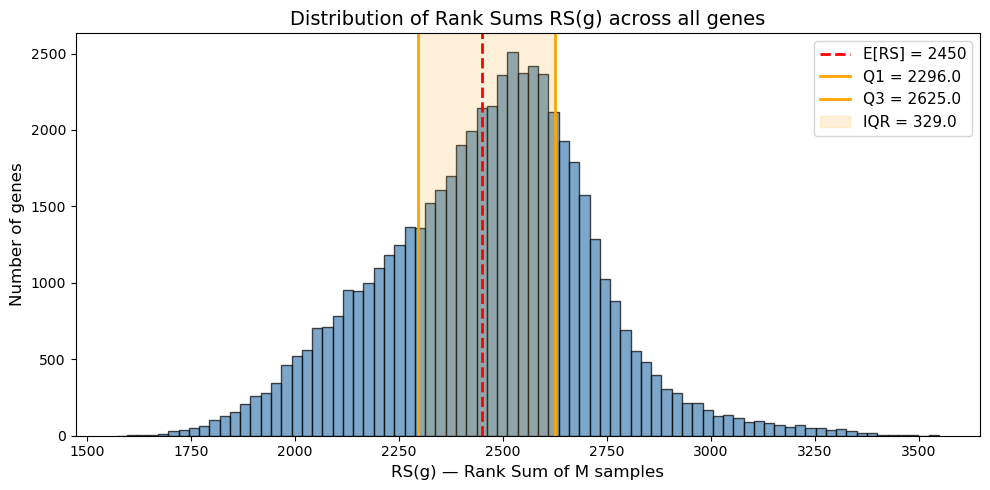

In [23]:
# --- 5) Compute RS(g) for every gene and draw histogram with IQR ---

# For each gene, rank all 99 samples and sum the ranks of the M samples.
# scipy.stats.rankdata ranks from 1 to N (average method for ties).
labels = sample_info.set_index('sample_id').loc[expr.columns, 'label'].values
is_M = (labels == 'M')

rank_sums = expr.apply(lambda row: stats.rankdata(row)[is_M].sum(), axis=1)

# IQR
Q1 = rank_sums.quantile(0.25)
Q3 = rank_sums.quantile(0.75)
IQR = Q3 - Q1

print(f'RS(g) statistics:')
print(f'  Min:    {rank_sums.min():.1f}')
print(f'  Q1:     {Q1:.1f}')
print(f'  Median: {rank_sums.median():.1f}')
print(f'  Q3:     {Q3:.1f}')
print(f'  Max:    {rank_sums.max():.1f}')
print(f'  IQR:    {IQR:.1f}')
print(f'  E[RS]:  {E_RS:.1f}')

# Histogram
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(rank_sums, bins=80, edgecolor='black', alpha=0.7, color='steelblue')

# Mark expected value
ax.axvline(E_RS, color='red', linestyle='--', linewidth=2, label=f'E[RS] = {E_RS:.0f}')

# Mark IQR
ax.axvline(Q1, color='orange', linestyle='-', linewidth=2, label=f'Q1 = {Q1:.1f}')
ax.axvline(Q3, color='orange', linestyle='-', linewidth=2, label=f'Q3 = {Q3:.1f}')
ax.axvspan(Q1, Q3, alpha=0.15, color='orange', label=f'IQR = {IQR:.1f}')

ax.set_xlabel('RS(g) — Rank Sum of M samples', fontsize=12)
ax.set_ylabel('Number of genes', fontsize=12)
ax.set_title('Distribution of Rank Sums RS(g) across all genes', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 3b Summary

| # | Question | Answer |
|---|----------|--------|
| 1 | $E[RS(g)]$ under $H_0$ | $n_M \cdot \frac{N+1}{2} = 49 \times 50 = 2450$ |
| 2 | Maximal value $c$ | $\sum_{k=51}^{99} k = 3675$ |
| 3 | $P(RS = c)$ | $\frac{1}{\binom{99}{49}} \approx 1.98 \times 10^{-29}$ — only 1 subset (top 49 ranks) out of $\binom{99}{49}$ achieves this sum |
| 4 | $P(RS = c{-}1)$ | $\frac{1}{\binom{99}{49}}$ — 1 subset: swap rank 51 for 50 |
|   | $P(RS = c{-}2)$ | $\frac{2}{\binom{99}{49}}$ — 2 subsets: swap 51→49 or 52→50 |
| 5 | RS(g) distribution | Centered near $E[RS]=2450$; IQR = 329 (Q1 = 2296, Q3 = 2625) |

### c. Differential Expression (DE) Analysis

For every gene $g$, we test for differential expression between M and H in **both one-sided directions**:

- **M > H (overexpressed in AMI):** $H_1$: expression in M is greater than in H
- **M < H (underexpressed in AMI):** $H_1$: expression in M is less than in H

using two statistical tests:
1. **Student's t-test** (`scipy.stats.ttest_ind`, one-sided)
2. **Wilcoxon Rank-Sum test** (`scipy.stats.mannwhitneyu`, one-sided)

We report the number of genes significant at $p \leq 0.07$.

In [19]:
# --- Compute one-sided p-values for every gene using both tests ---

alpha = 0.07

# Pre-extract the M and H matrices as numpy arrays for speed
M_vals = expr_ami.values.T   # shape (n_M, n_genes) after transpose? No — expr_ami is (genes, n_M)
H_vals = expr_healthy.values.T

# We'll iterate over genes (rows of expr)
t_pvals_greater = []  # t-test, H1: M > H
t_pvals_less = []     # t-test, H1: M < H
w_pvals_greater = []  # WRS,    H1: M > H
w_pvals_less = []     # WRS,    H1: M < H

for gene in expr.index:
    m = expr_ami.loc[gene].values.astype(float)
    h = expr_healthy.loc[gene].values.astype(float)

    # Student t-test (two-sample, equal_var=True for classic Student's t)
    _, p_t_greater = stats.ttest_ind(m, h, alternative='greater')
    _, p_t_less    = stats.ttest_ind(m, h, alternative='less')

    # Wilcoxon Rank-Sum (Mann-Whitney U)
    _, p_w_greater = stats.mannwhitneyu(m, h, alternative='greater')
    _, p_w_less    = stats.mannwhitneyu(m, h, alternative='less')

    t_pvals_greater.append(p_t_greater)
    t_pvals_less.append(p_t_less)
    w_pvals_greater.append(p_w_greater)
    w_pvals_less.append(p_w_less)

# Store results in a DataFrame
de_results = pd.DataFrame({
    'ttest_M_gt_H': t_pvals_greater,
    'ttest_M_lt_H': t_pvals_less,
    'wrs_M_gt_H':   w_pvals_greater,
    'wrs_M_lt_H':   w_pvals_less,
}, index=expr.index)
de_results.index.name = 'probe_id'

print('DE p-value table (first 10 genes):')
de_results.head(10)

DE p-value table (first 10 genes):


,ttest_M_gt_H,ttest_M_lt_H,wrs_M_gt_H,wrs_M_lt_H
probe_id,,,,
1007_s_at,0.897953,0.102047,0.847386,0.154271
1053_at,0.327719,0.672281,0.141349,0.860213
117_at,0.000053,0.999947,0.000009,0.999991
121_at,0.459246,0.540754,0.265536,0.736753
1255_g_at,0.315798,0.684202,0.150969,0.850664
1294_at,0.894440,0.105560,0.953827,0.046854
1316_at,0.997592,0.002408,0.998975,0.001049
1320_at,0.009004,0.990996,0.046173,0.954500
1405_i_at,0.983175,0.016825,0.998260,0.001779


In [20]:
# --- Report number of significant DE genes at p <= 0.07 ---

print(f'Significance threshold: p <= {alpha}')
print(f'Total genes tested: {len(de_results)}')
print()
print('Overexpressed in M vs H (M > H):')
print(f'  Student t-test: {(de_results["ttest_M_gt_H"] <= alpha).sum()} genes')
print(f'  WRS test:       {(de_results["wrs_M_gt_H"]   <= alpha).sum()} genes')
print()
print('Underexpressed in M vs H (M < H):')
print(f'  Student t-test: {(de_results["ttest_M_lt_H"] <= alpha).sum()} genes')
print(f'  WRS test:       {(de_results["wrs_M_lt_H"]   <= alpha).sum()} genes')

Significance threshold: p <= 0.07
Total genes tested: 54628

Overexpressed in M vs H (M > H):
  Student t-test: 8517 genes
  WRS test:       10721 genes

Underexpressed in M vs H (M < H):
  Student t-test: 8639 genes
  WRS test:       10618 genes


### 3c Summary

Number of differentially expressed genes at $p \leq 0.07$ (out of 54,628 genes):

| Direction | Student t-test | WRS test |
|-----------|---------------|----------|
| **M > H** (overexpressed in AMI) | 8,517 | 10,721 |
| **M < H** (underexpressed in AMI) | 8,639 | 10,618 |

The WRS test identifies more significant genes in both directions compared to the Student t-test.

### d. Correlations and Co-expression

We select the **80 most significant genes** from each one-sided WRS DE list:
- 80 genes most overexpressed in M vs H (smallest `wrs_M_gt_H` p-values)
- 80 genes most underexpressed in M vs H (smallest `wrs_M_lt_H` p-values)

The union of these two sets forms **D** (up to 160 genes).

In [21]:
# --- Build gene set D: union of top-80 overexpressed and top-80 underexpressed (WRS) ---

top80_over  = de_results['wrs_M_gt_H'].nsmallest(80).index.tolist()
top80_under = de_results['wrs_M_lt_H'].nsmallest(80).index.tolist()

D = list(dict.fromkeys(top80_over + top80_under))  # union, preserving order

print(f'Top 80 overexpressed (M > H):  {len(top80_over)} genes')
print(f'Top 80 underexpressed (M < H): {len(top80_under)} genes')
print(f'Overlap: {len(set(top80_over) & set(top80_under))} genes')
print(f'Gene set D (union): {len(D)} genes')

Top 80 overexpressed (M > H):  80 genes
Top 80 underexpressed (M < H): 80 genes
Overlap: 0 genes
Gene set D (union): 160 genes


#### 1) Kendall $\tau$ correlation heatmap for all pairs in D

Kendall tau correlation matrix shape: (160, 160)
Number of unique pairs: 12720


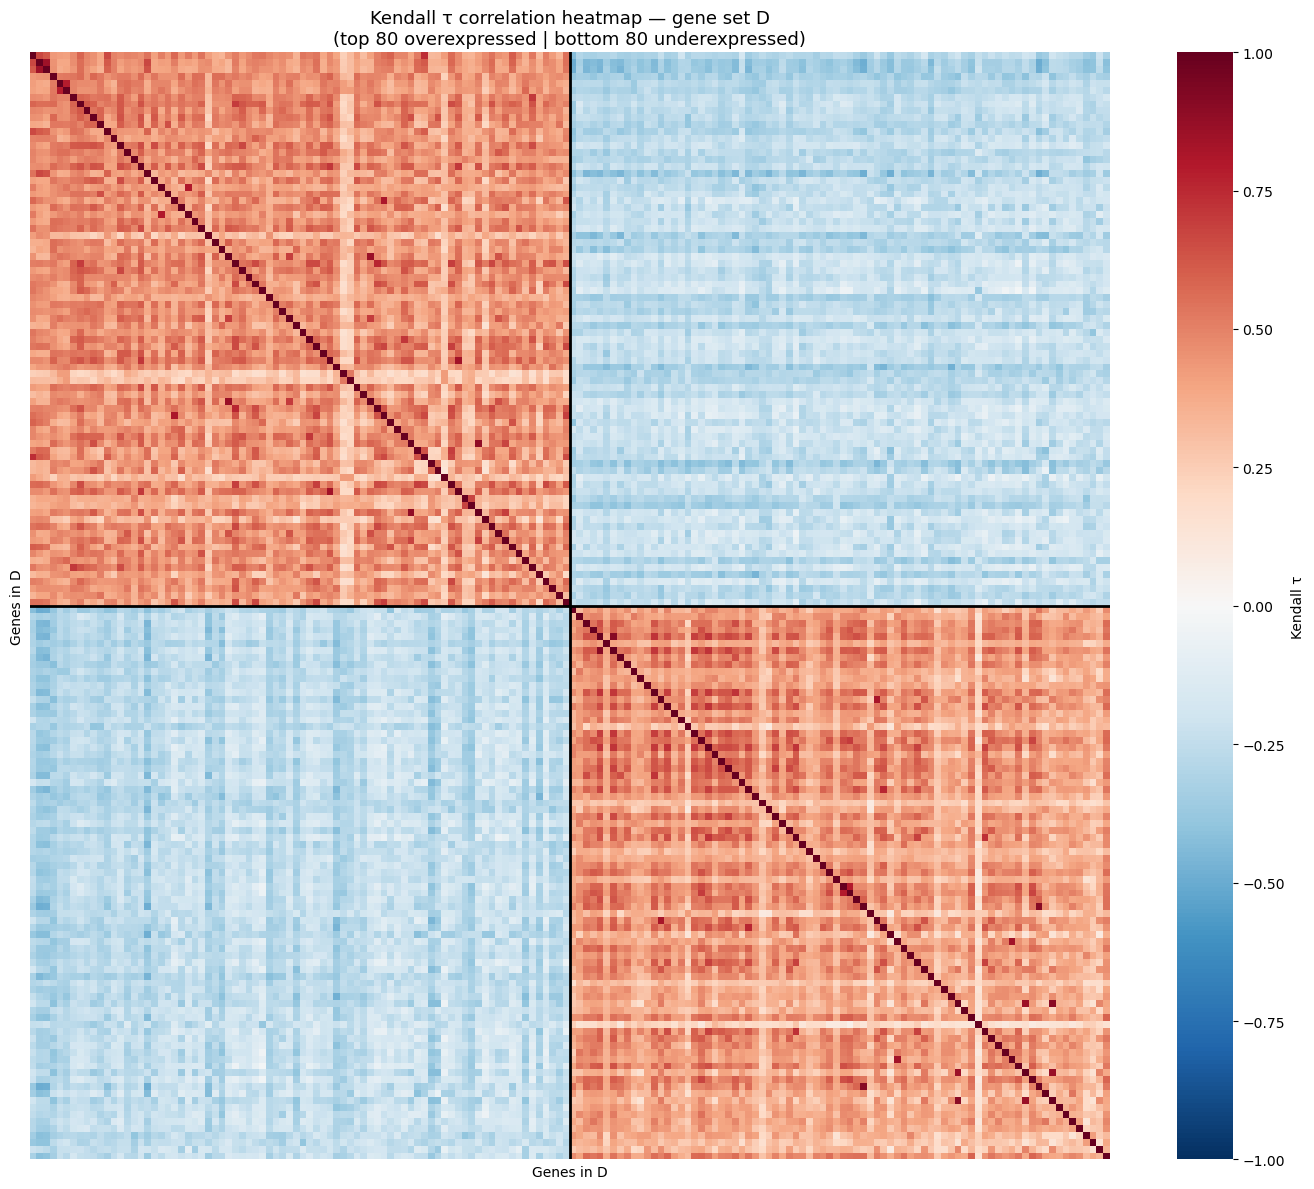

In [23]:
# --- 1) Kendall tau correlation matrix for gene set D ---
# Transpose so that rows=samples, columns=genes (corr computes column-wise)
expr_D = expr.loc[D].T  # shape: (99 samples, |D| genes)

kendall_corr = expr_D.corr(method='kendall')

print(f'Kendall tau correlation matrix shape: {kendall_corr.shape}')
print(f'Number of unique pairs: {len(D) * (len(D)-1) // 2}')

# Heatmap
fig, ax = plt.subplots(figsize=(14, 12))

# Order: overexpressed first, then underexpressed-only
order = top80_over + [g for g in top80_under if g not in top80_over]
kendall_ordered = kendall_corr.loc[order, order]

sns.heatmap(kendall_ordered, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=False, yticklabels=False, ax=ax,
            cbar_kws={'label': 'Kendall τ'})

# Add a dividing line between over- and under-expressed blocks
n_over = len(top80_over)
ax.axhline(y=n_over, color='black', linewidth=2)
ax.axvline(x=n_over, color='black', linewidth=2)

ax.set_title('Kendall τ correlation heatmap — gene set D\n'
             f'(top {n_over} overexpressed | bottom {len(D)-n_over} underexpressed)',
             fontsize=13)
ax.set_xlabel('Genes in D')
ax.set_ylabel('Genes in D')
plt.tight_layout()
plt.show()

#### 2) Expected value of Kendall $\tau$ under the null

Under a null model that assumes **pairwise independence** between genes, the expression values of any two genes are independent random variables. The Kendall $\tau$ statistic measures the degree of concordance between two rankings. For independent variables, concordant and discordant pairs are equally likely, so:

$$E[\tau] = 0$$

In other words, under independence, we expect no systematic tendency for pairs of samples to be ranked in the same order across two genes.

#### 3) Kendall $\tau$ among the 80 overexpressed genes

Number of overexpressed gene pairs: C(80,2) = 3160
Average Kendall τ among overexpressed pairs: 0.4363
Expected τ under null (independence):        0.0000

The observed average τ = 0.4363 is substantially greater than 0,
indicating that overexpressed genes tend to be positively co-expressed.


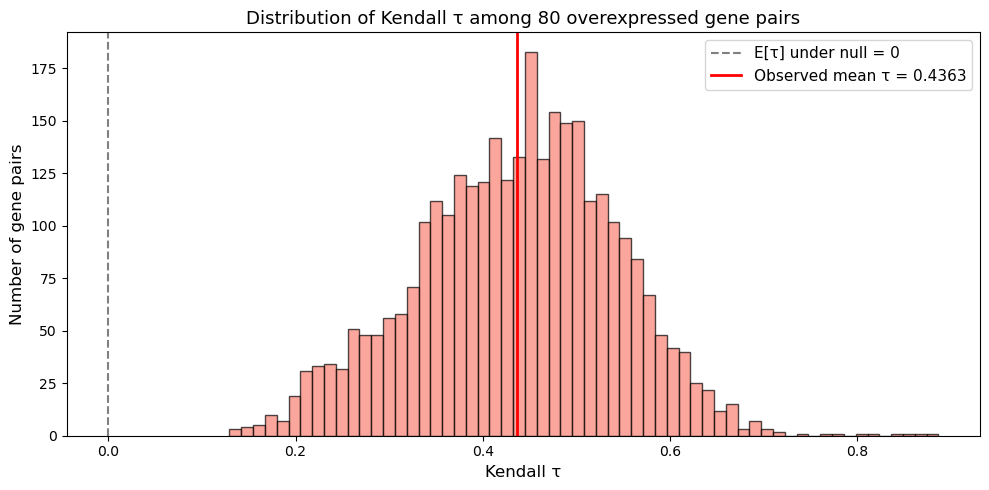

In [24]:
# --- 3) Kendall tau for all pairs within the 80 overexpressed genes ---

# Extract the sub-matrix of the already-computed Kendall correlation
kendall_over = kendall_corr.loc[top80_over, top80_over]

# Get the upper triangle (excluding diagonal) — these are the C(80,2) = 3160 unique pairs
mask_upper = np.triu(np.ones(kendall_over.shape, dtype=bool), k=1)
tau_over_pairs = kendall_over.values[mask_upper]

n_pairs = len(tau_over_pairs)
mean_tau = tau_over_pairs.mean()

print(f'Number of overexpressed gene pairs: C(80,2) = {n_pairs}')
print(f'Average Kendall τ among overexpressed pairs: {mean_tau:.4f}')
print(f'Expected τ under null (independence):        0.0000')
print(f'\nThe observed average τ = {mean_tau:.4f} is substantially greater than 0,')
print(f'indicating that overexpressed genes tend to be positively co-expressed.')

# Histogram
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(tau_over_pairs, bins=60, edgecolor='black', alpha=0.7, color='salmon')
ax.axvline(0, color='gray', linestyle='--', linewidth=1.5, label='E[τ] under null = 0')
ax.axvline(mean_tau, color='red', linestyle='-', linewidth=2, label=f'Observed mean τ = {mean_tau:.4f}')

ax.set_xlabel('Kendall τ', fontsize=12)
ax.set_ylabel('Number of gene pairs', fontsize=12)
ax.set_title('Distribution of Kendall τ among 80 overexpressed gene pairs', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

**Explanation:** The average Kendall $\tau$ among the 80 overexpressed genes is substantially positive (far from 0). This is expected because these genes were all selected for being overexpressed in the same direction (M > H). Samples from AMI patients tend to have consistently high expression across these genes, while healthy samples tend to have consistently low expression. This shared response to the AMI condition creates **positive concordance** across samples, driving $\tau$ well above the null expectation of 0.

#### 4) Co-expression in D

In [25]:
# --- 4) Co-expression analysis within D ---

# Extract all unique pairwise tau values from the full D correlation matrix
mask_full = np.triu(np.ones(kendall_corr.loc[D, D].shape, dtype=bool), k=1)
tau_all_D = kendall_corr.loc[D, D].values[mask_full]

# Also extract cross-block correlations (over vs under)
kendall_cross = kendall_corr.loc[top80_over, [g for g in top80_under if g not in top80_over]]
tau_cross = kendall_cross.values.flatten()

# tau among underexpressed
kendall_under = kendall_corr.loc[top80_under, top80_under]
mask_under = np.triu(np.ones(kendall_under.shape, dtype=bool), k=1)
tau_under_pairs = kendall_under.values[mask_under]

print('Co-expression summary for gene set D:')
print(f'  All pairs in D:           mean τ = {tau_all_D.mean():.4f}  (n = {len(tau_all_D)})')
print(f'  Over–Over pairs:          mean τ = {tau_over_pairs.mean():.4f}  (n = {len(tau_over_pairs)})')
print(f'  Under–Under pairs:        mean τ = {tau_under_pairs.mean():.4f}  (n = {len(tau_under_pairs)})')
print(f'  Over–Under (cross) pairs: mean τ = {tau_cross.mean():.4f}  (n = {len(tau_cross)})')

Co-expression summary for gene set D:
  All pairs in D:           mean τ = 0.0844  (n = 12720)
  Over–Over pairs:          mean τ = 0.4363  (n = 3160)
  Under–Under pairs:        mean τ = 0.4064  (n = 3160)
  Over–Under (cross) pairs: mean τ = -0.2483  (n = 6400)


**Observations on co-expression in D:**

The heatmap and the numerical summaries reveal a clear **block structure**:

1. **Over–Over block (positive τ):** Genes overexpressed in M are positively correlated with each other — when one is up in a sample, the others tend to be up too. These genes are **co-expressed** as part of the AMI response.

2. **Under–Under block (positive τ):** Similarly, genes underexpressed in M are positively correlated with each other — they tend to go down together in AMI samples.

3. **Over–Under cross-block (negative τ):** Overexpressed and underexpressed genes are **negatively correlated** — when the overexpressed genes are high (AMI samples), the underexpressed genes are low, and vice versa.

This pattern reflects the fact that the AMI condition drives a coordinated transcriptional program: a set of genes is upregulated while another set is downregulated. The two-class (M vs H) structure in the data induces strong co-expression within each direction and anti-correlation across directions.

#### 5) Co-expressed pairs at FDR = 0.05 in the entire dataset

To count how many gene–gene pairs are co-expressed at an FDR of 0.05, we would conceptually perform a Kendall $\tau$ test for every possible pair of genes. For $G \approx 55{,}000$ genes, the total number of pairwise tests is:

$$m = \binom{G}{2} = \frac{G(G-1)}{2} \approx 1.5 \times 10^9$$

We then apply the **Benjamini–Hochberg (BH)** procedure with an FDR threshold of $\alpha = 0.05$ (using $\alpha$ here to avoid confusion with Kendall's $\tau$). We sort the p-values:

$$p_{(1)} \le p_{(2)} \le \cdots \le p_{(m)}$$

And find the largest $k$ such that:

$$p_{(k)} \le \frac{k}{m}\alpha$$

The number of discoveries (significant co-expressed pairs) is $k$. 

* **Under the global null** (all gene pairs are independent), p-values are approximately Uniform $[0,1]$. Because $m$ is enormous, the BH thresholds $\frac{k}{m}\alpha$ are extremely small, meaning we would expect **very few discoveries, often zero** under the global null.
* **In this specific dataset**, we would likely observe a **non-zero (and potentially large)** number of significant co-expressed pairs after BH at FDR = 0.05, but the exact $k$ cannot be stated without running the full $\binom{G}{2}$ testing procedure. 

**Why k could be large:**
This explosion of significant pairs happens because the data contains a strong two-class structure (AMI vs. Healthy). The clinical condition acts as a massive, dominant biological confounder. Hundreds or thousands of genes are differentially expressed in a coordinated way in response to the heart attack. 

Because we are calculating correlations across *all* samples combined, many pairs of genes that shift with the class label (e.g., both up in AMI or both down in AMI) can exhibit strong apparent correlation driven by the shared condition. Their resulting p-values can be extremely small—sometimes small enough to survive even the stringent multiple testing penalty. Therefore, at FDR = 0.05, the BH procedure could report a large network of statistically significant co-expressed pairs, primarily driven by the shared clinical condition rather than direct, independent gene-to-gene regulatory interactions.

#### 6) Advantages and disadvantages of computing co-expression for all genes vs only D

**Advantages of using all genes:**
- **Unbiased discovery:** No pre-selection bias — co-expression is assessed without restricting to DE genes, so we can detect co-expression among genes that are not differentially expressed (e.g., housekeeping gene modules, tissue-specific programs).
- **Complete network:** Enables construction of a full gene co-expression network (e.g., WGCNA), which can reveal functional modules and hub genes that may not appear in D.
- **No information loss:** Subtle but real co-expression patterns that don't reach DE significance are still captured.

**Disadvantages of using all genes:**
- **Computational cost:** $\binom{54628}{2} \approx 1.49 \times 10^{9}$ pairs require enormous computation, especially for Kendall $\tau$ which is $O(n \log n)$ per pair.
- **Severe multiple testing burden:** With ~1.5 billion tests, FDR correction becomes very stringent — only very strong correlations will survive, and statistical power for moderate effects drops.
- **Noise dominance:** Most gene pairs involve non-DE genes with weak or no biological signal, so the results are dominated by noise, making it harder to interpret the output.
- **Confounded co-expression:** The two-class structure (M vs H) induces spurious correlation among DE genes; mixing these with non-DE genes makes it hard to distinguish condition-driven from intrinsic co-expression.

**In summary:** Computing co-expression only within D is a practical compromise — it focuses on biologically relevant genes, is computationally feasible, and the multiple testing burden is manageable ($\binom{160}{2} = 12{,}720$ tests vs ~1.5 billion). The trade-off is that we may miss co-expression among non-DE genes.

### 3d Summary

| # | Question | Answer |
|---|----------|--------|
| 1 | Kendall τ heatmap | 160×160 matrix showing clear block structure: positive τ within over/under blocks, negative τ across blocks |
| 2 | $E[\tau]$ under null (independence) | **0** — concordant and discordant pairs are equally likely |
| 3 | Mean τ among 80 overexpressed pairs | **0.4363** (3,160 pairs) — far above 0, because these genes share the same direction of DE driven by the AMI condition |
| 4 | Co-expression in D | Over–Over: mean τ = 0.44, Under–Under: mean τ = 0.41 (positive co-expression within blocks); Over–Under: mean τ = −0.25 (anti-correlation across blocks) |
| 5 | Co-expressed pairs at FDR=0.05 (full dataset) | We would observe many significant pairs — the two-class structure creates genuine widespread co-expression among DE genes; FDR ensures ≤5% false discoveries |
| 6 | All genes vs D only | All genes: unbiased, complete network, but ~1.5B tests (computational cost, noise, severe multiple testing). D only: focused, feasible, manageable testing burden, but may miss non-DE co-expression |

### e. Plots and Conclusions

#### 1) DE Overabundance Plots

For the one-sided WRS and t-test (M > H overexpression), we sort genes by p-value and plot:
- **Blue line:** $k$ — the observed number of genes at rank $k$ (identity)
- **Green line:** $m \cdot p_{(k)}$ — the expected number of genes with p-value $\leq p_{(k)}$ under the null

The gap between blue and green represents **overabundance** of DE genes beyond chance.

FDR at rank $k$ is $\frac{m \cdot p_{(k)}}{k}$ (Benjamini–Hochberg). We find the largest $k$ where FDR $\leq \tau$.

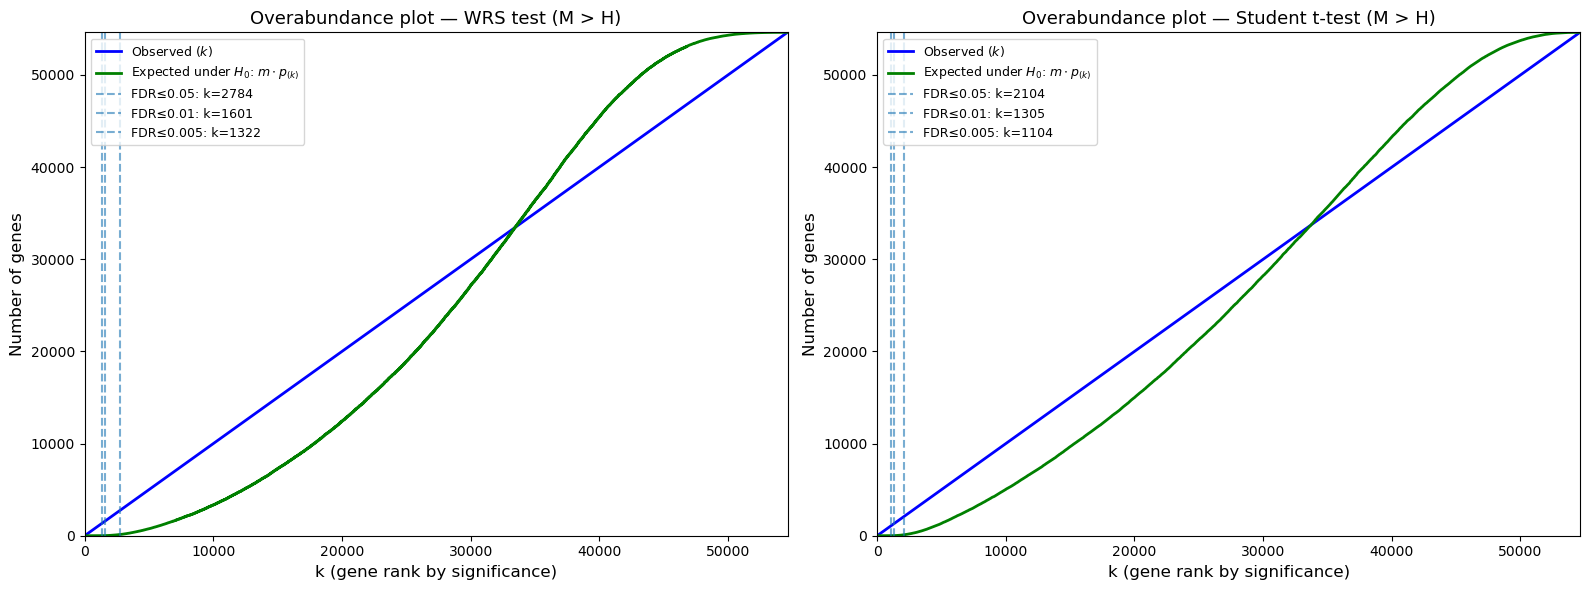

Number of DE genes (M > H) at BH-FDR threshold:
                       WRS     t-test
  FDR≤0.05         2784       2104
  FDR≤0.01         1601       1305
  FDR≤0.005        1322       1104


In [26]:
# --- 1) DE Overabundance plots for M > H (WRS and t-test) ---

def bh_fdr_count(pvals_sorted, tau):
    """Find largest k where p_(k) <= k * tau / m (BH procedure)."""
    m = len(pvals_sorted)
    k_vals = np.arange(1, m + 1)
    threshold = k_vals * tau / m
    passing = np.where(pvals_sorted <= threshold)[0]
    return int(passing[-1] + 1) if len(passing) > 0 else 0

m = len(de_results)
fdr_thresholds = [0.05, 0.01, 0.005]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, test_name, col in zip(axes, ['WRS test', 'Student t-test'],
                               ['wrs_M_gt_H', 'ttest_M_gt_H']):
    pvals = de_results[col].sort_values().values
    k = np.arange(1, m + 1)
    expected = m * pvals  # green line: m * p_(k)

    ax.plot(k, k, color='blue', linewidth=2, label='Observed ($k$)')
    ax.plot(k, expected, color='green', linewidth=2, label=r'Expected under $H_0$: $m \cdot p_{(k)}$')

    # Mark FDR thresholds
    for tau in fdr_thresholds:
        k_fdr = bh_fdr_count(pvals, tau)
        if k_fdr > 0:
            ax.axvline(k_fdr, linestyle='--', alpha=0.6,
                       label=f'FDR≤{tau}: k={k_fdr}')

    ax.set_xlabel('k (gene rank by significance)', fontsize=12)
    ax.set_ylabel('Number of genes', fontsize=12)
    ax.set_title(f'Overabundance plot — {test_name} (M > H)', fontsize=13)
    ax.legend(fontsize=9, loc='upper left')
    ax.set_xlim(0, m)
    ax.set_ylim(0, m)

plt.tight_layout()
plt.show()

# Report FDR results
print('Number of DE genes (M > H) at BH-FDR threshold:')
print(f'{"":>15} {"WRS":>10} {"t-test":>10}')
for tau in fdr_thresholds:
    k_wrs = bh_fdr_count(de_results['wrs_M_gt_H'].sort_values().values, tau)
    k_t   = bh_fdr_count(de_results['ttest_M_gt_H'].sort_values().values, tau)
    wrs_str = str(k_wrs) if k_wrs > 0 else 'none (k=0)'
    t_str   = str(k_t)   if k_t > 0   else 'none (k=0)'
    print(f'  FDR≤{tau:<6} {wrs_str:>10} {t_str:>10}')

#### 2) Robust Differentially Expressed Genes (RDEG)

For each gene $g$, we consider all 99 possible single-label swaps (flipping one sample's label M↔H). For each swap $\lambda$, we recompute the WRS one-sided p-value for M > H overexpression.

$$p_U(g) = \max_\lambda S(g) = \text{worst-case p-value under a single labeling error}$$

We then run BH-FDR at $\tau = 0.05$ using $p_U(g)$ instead of the original p-values. Genes that survive are **robust** to any single labeling error.

In [27]:
# --- 2a) Compute p_U(g) for all genes ---
# For efficiency, we use the rank-based normal approximation for Mann-Whitney U.
# For each of 99 swaps, we vectorize over all genes.

from scipy.stats import norm

# Precompute ranks for all genes (across samples)
ranks_matrix = expr.rank(axis=1)  # each row: ranks 1..99 for that gene

# Original label mask
is_M_orig = np.array([s in ami_samples for s in expr.columns])  # shape (99,)

# Initialize p_U with zeros — will track the maximum p-value across swaps
p_U = np.zeros(len(expr))

for swap_idx in range(N):
    # Flip one label
    is_M_swap = is_M_orig.copy()
    is_M_swap[swap_idx] = ~is_M_swap[swap_idx]

    n_M_s = is_M_swap.sum()
    n_H_s = N - n_M_s

    # Rank sum of M group for all genes at once
    RS_swap = ranks_matrix.iloc[:, is_M_swap].sum(axis=1).values

    # Mann-Whitney U statistic
    U_swap = RS_swap - n_M_s * (n_M_s + 1) / 2

    # Normal approximation (with continuity correction)
    E_U = n_M_s * n_H_s / 2
    Var_U = n_M_s * n_H_s * (N + 1) / 12
    z = (U_swap - E_U) / np.sqrt(Var_U)

    # One-sided p-value for M > H
    p_swap = norm.sf(z)  # sf = 1 - cdf, numerically stable

    # Update max
    p_U = np.maximum(p_U, p_swap)

p_U_series = pd.Series(p_U, index=expr.index, name='p_U')
print(f'p_U computed for {len(p_U_series)} genes')
print(f'p_U range: [{p_U_series.min():.6f}, {p_U_series.max():.6f}]')
print(f'Median p_U: {p_U_series.median():.4f}')

p_U computed for 54628 genes
p_U range: [0.000000, 1.000000]
Median p_U: 0.5460


In [28]:
# --- 2b) BH-FDR at tau=0.05 using p_U(g) ---
p_U_sorted = p_U_series.sort_values().values
k_rdeg = bh_fdr_count(p_U_sorted, tau=0.05)

print(f'BH-FDR at τ=0.05 using p_U (robust p-values):')
print(f'  Number of Robust DE genes (RDEG): {k_rdeg}')

# --- 2c) Intersection with Q1a results ---
# 1a: genes significant at FDR=0.05 using original WRS p-values
pvals_wrs_sorted = de_results['wrs_M_gt_H'].sort_values()
k_q1a = bh_fdr_count(pvals_wrs_sorted.values, tau=0.05)

# Get the actual gene sets
genes_q1a = set(pvals_wrs_sorted.index[:k_q1a])
genes_rdeg = set(p_U_series.sort_values().index[:k_rdeg])

intersection = genes_q1a & genes_rdeg

print(f'\nOriginal WRS FDR≤0.05 genes (Q1a):  {len(genes_q1a)}')
print(f'Robust DE genes (RDEG, FDR≤0.05):   {len(genes_rdeg)}')
print(f'Intersection:                         {len(intersection)}')
print(f'RDEG that are NOT in Q1a:             {len(genes_rdeg - genes_q1a)}')
print(f'Q1a genes that are NOT RDEG:          {len(genes_q1a - genes_rdeg)}')

BH-FDR at τ=0.05 using p_U (robust p-values):
  Number of Robust DE genes (RDEG): 1847

Original WRS FDR≤0.05 genes (Q1a):  2784
Robust DE genes (RDEG, FDR≤0.05):   1847
Intersection:                         1847
RDEG that are NOT in Q1a:             0
Q1a genes that are NOT RDEG:          937


**Explanation (Q2c):**

The RDEG set is a **subset** of (or equal to) the original Q1a set. This is because $p_U(g) \geq p_{\text{original}}(g)$ for every gene — the worst-case p-value after a label swap is always at least as large as the original. Consequently, the BH procedure applied to the inflated $p_U$ values is strictly more conservative: any gene that survives the robust criterion must also survive the original criterion, so RDEG $\subseteq$ Q1a.

The genes in Q1a but not in RDEG are those whose significance is **fragile** — a single labeling error could push their p-value above the FDR threshold. The RDEG genes are those whose DE signal is strong enough to withstand any single mislabeling.

#### 3) Expression patterns of 3 selected DE genes from D

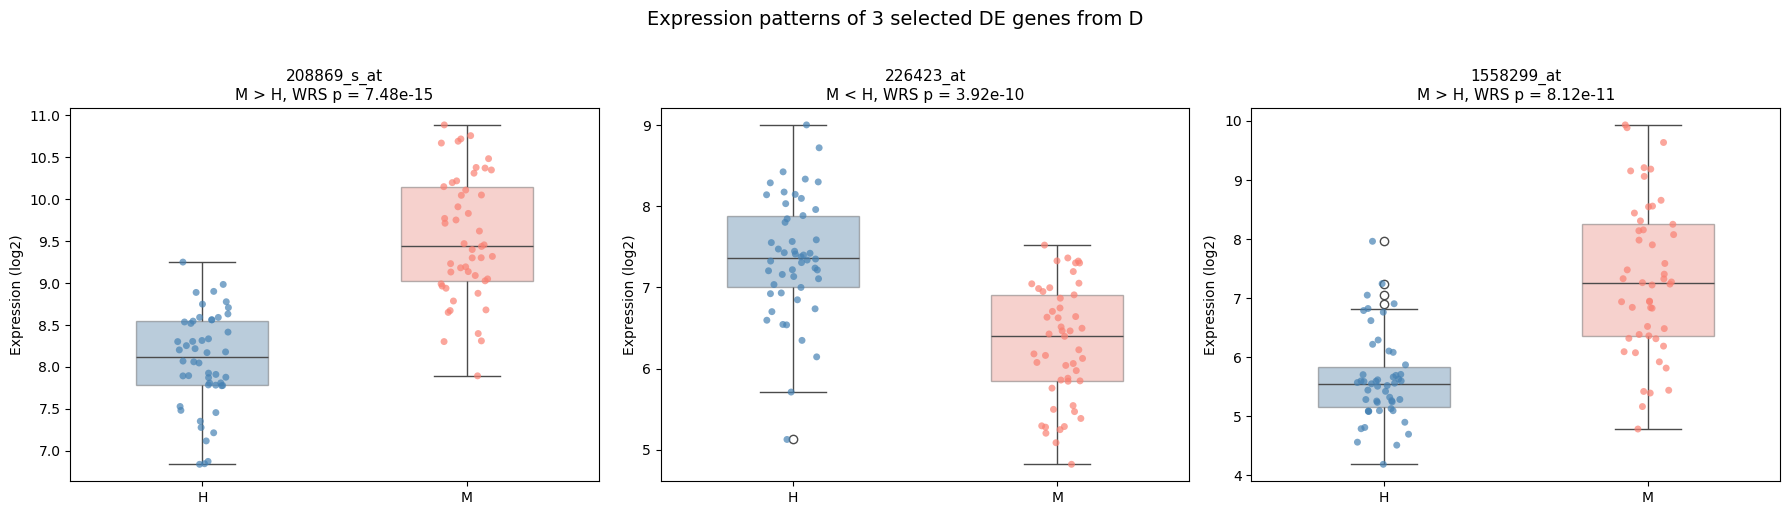

In [29]:
# --- 3) Select 3 DE genes from D and visualize ---
# Pick the most significant overexpressed, most significant underexpressed,
# and one with moderate effect from D.
gene_over  = de_results.loc[top80_over, 'wrs_M_gt_H'].idxmin()   # best overexpressed
gene_under = de_results.loc[top80_under, 'wrs_M_lt_H'].idxmin()  # best underexpressed
gene_mid   = top80_over[39]  # a middle-ranked overexpressed gene

selected_genes = [gene_over, gene_under, gene_mid]
labels_arr = sample_info.set_index('sample_id').loc[expr.columns, 'label'].values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, gene in zip(axes, selected_genes):
    gene_data = pd.DataFrame({
        'Expression': expr.loc[gene].values,
        'Class': labels_arr
    })

    # Strip plot with overlaid box
    sns.boxplot(data=gene_data, x='Class', y='Expression', hue='Class',
                order=['H', 'M'], hue_order=['H', 'M'],
                palette={'H': 'steelblue', 'M': 'salmon'},
                ax=ax, legend=False, width=0.5, showcaps=True,
                boxprops=dict(alpha=0.4))
    sns.stripplot(data=gene_data, x='Class', y='Expression', hue='Class',
                  order=['H', 'M'], hue_order=['H', 'M'],
                  palette={'H': 'steelblue', 'M': 'salmon'},
                  ax=ax, legend=False, size=5, alpha=0.7, jitter=True)

    # Annotate with p-values
    p_wrs_gt = de_results.loc[gene, 'wrs_M_gt_H']
    p_wrs_lt = de_results.loc[gene, 'wrs_M_lt_H']
    direction = 'M > H' if p_wrs_gt < p_wrs_lt else 'M < H'
    p_best = min(p_wrs_gt, p_wrs_lt)

    ax.set_title(f'{gene}\n{direction}, WRS p = {p_best:.2e}', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Expression (log2)')

fig.suptitle('Expression patterns of 3 selected DE genes from D', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### 4) Heatmap of gene set D across all samples

We order genes and samples using hierarchical clustering to produce maximal visual contrast between the M and H groups.

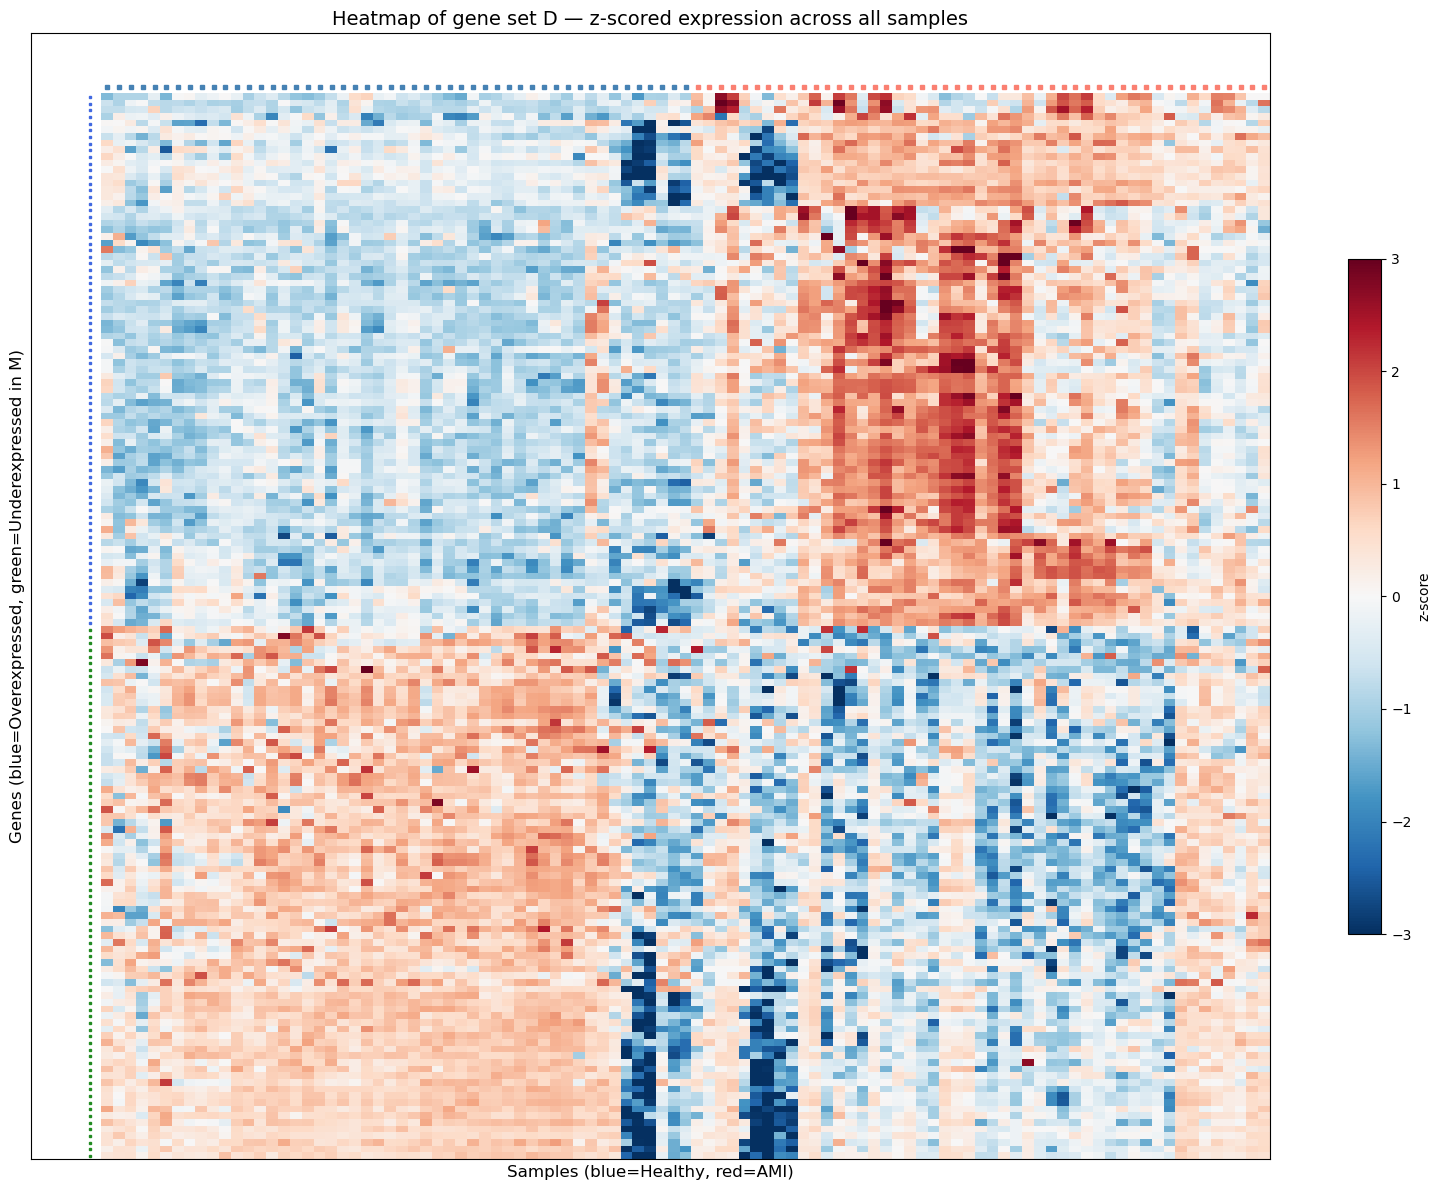

In [30]:
# --- 4) Heatmap of D across all samples ---
# Order genes: overexpressed first, then underexpressed (within each block, cluster)
# Order samples: group by class (H then M), cluster within each group

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

# Prepare expression matrix for D, z-scored per gene for better visualization
expr_D_full = expr.loc[D]
expr_D_z = expr_D_full.subtract(expr_D_full.mean(axis=1), axis=0).div(expr_D_full.std(axis=1), axis=0)

# --- Order genes by block, then cluster within block ---
def cluster_order(data_matrix):
    """Return row indices ordered by hierarchical clustering."""
    if data_matrix.shape[0] <= 1:
        return list(range(data_matrix.shape[0]))
    dist = pdist(data_matrix, metric='correlation')
    Z = linkage(dist, method='average')
    return leaves_list(Z).tolist()

over_only  = [g for g in top80_over]
under_only = [g for g in top80_under if g not in top80_over]

over_order  = [over_only[i]  for i in cluster_order(expr_D_z.loc[over_only].values)]
under_order = [under_only[i] for i in cluster_order(expr_D_z.loc[under_only].values)]
gene_order  = over_order + under_order

# --- Order samples: H first, M second; cluster within each group ---
h_cols = [s for s in expr.columns if s in healthy_samples]
m_cols = [s for s in expr.columns if s in ami_samples]

h_order = [h_cols[i] for i in cluster_order(expr_D_z[h_cols].T.values)]
m_order = [m_cols[i] for i in cluster_order(expr_D_z[m_cols].T.values)]
sample_order = h_order + m_order

# --- Build color annotations ---
col_colors = ['steelblue'] * len(h_order) + ['salmon'] * len(m_order)
row_colors = ['royalblue'] * len(over_order) + ['forestgreen'] * len(under_order)

# --- Draw heatmap ---
fig, ax = plt.subplots(figsize=(16, 12))

heatmap_data = expr_D_z.loc[gene_order, sample_order]

im = ax.imshow(heatmap_data.values, aspect='auto', cmap='RdBu_r',
               vmin=-3, vmax=3, interpolation='none')

# Color bar for column classes (top)
for j, c in enumerate(col_colors):
    ax.plot(j, -1.5, 's', color=c, markersize=3, clip_on=False)

# Color bar for row classes (left)
for i, c in enumerate(row_colors):
    ax.plot(-1.5, i, 's', color=c, markersize=2, clip_on=False)

ax.set_xlabel('Samples (blue=Healthy, red=AMI)', fontsize=12)
ax.set_ylabel('Genes (blue=Overexpressed, green=Underexpressed in M)', fontsize=12)
ax.set_title('Heatmap of gene set D — z-scored expression across all samples', fontsize=14)
ax.set_xticks([])
ax.set_yticks([])

cbar = plt.colorbar(im, ax=ax, shrink=0.6, label='z-score')
plt.tight_layout()
plt.show()

### 3e Summary

**1) — DE Overabundance (M > H):**

| FDR threshold ($\tau$) | WRS test | Student t-test |
|------------------------|---------|---------------|
| 0.05 | 2,784 | 2,104 |
| 0.01 | 1,601 | 1,305 |
| 0.005 | 1,322 | 1,104 |

**2) — Robust DE Genes (RDEG):**
- $p_U(g)$ = worst-case WRS p-value after any single label swap
- RDEG at FDR $\leq$ 0.05: **1,847 genes**
- Original WRS FDR $\leq$ 0.05: **2,784 genes**
- **Intersection = 1,847** (RDEG $\subseteq$ Q1a) — all RDEG are a subset of the original; 937 genes from Q1a were too fragile to survive a single label swap

**3):** Three DE genes from D visualized with box+strip plots, showing clear separation between H and M.

**4):** Heatmap of D (160 genes × 99 samples), z-scored and hierarchically clustered, reveals a striking two-block pattern: overexpressed genes are high in M/low in H, underexpressed genes show the opposite — confirming the coordinated transcriptional response to AMI.